# Midterm Project

For this project we will use the [Gaia DR3 data release](https://gea.esac.esa.int/archive/) to explore the solar neighborhood. This is the same selection of data we've explored recently, which can be pulled from the Gaia data archive with the following query:

```sql
SELECT TOP 300000 phot_g_mean_mag+5*log10(parallax)-10 AS mg, bp_rp, parallax FROM gaiadr3.gaia_source
WHERE parallax_over_error > 10
AND parallax > 10
AND phot_g_mean_flux_over_error>50
AND phot_rp_mean_flux_over_error>20
AND phot_bp_mean_flux_over_error>20
AND phot_bp_rp_excess_factor < 1.3+0.06*power(phot_bp_mean_mag-phot_rp_mean_mag,2)
AND phot_bp_rp_excess_factor > 1.0+0.015*power(phot_bp_mean_mag-phot_rp_mean_mag,2)
AND visibility_periods_used>8
AND astrometric_chi2_al/(astrometric_n_good_obs_al-5)<1.44*greatest(1,exp(-0.4*(phot_g_mean_mag-19.5)))
```

The data is also in the `data/` directory of this repository.

Using a subset of this data, we're going to focus on constructing models and inferring the parameters of those models using `NumPyro`.

In [2]:
import numpy as np
import numpyro.distributions as dist
import numpyro
numpyro.set_host_device_count(2)
from numpyro import infer
import jax
import jax.numpy as jnp
from jax import random
print(jax.local_device_count())
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import time

2


## Data Down-Selection

To avoid lengthy run times we'll focus on only the nearby data.  Select out the objects with parallax > 40 milliarcseconds.

# Part I

For this part we'll remove (crudely) the white dwarf population (the dim secondary population of stars).  To do this we'll use a simple linear boundary to divide the population:

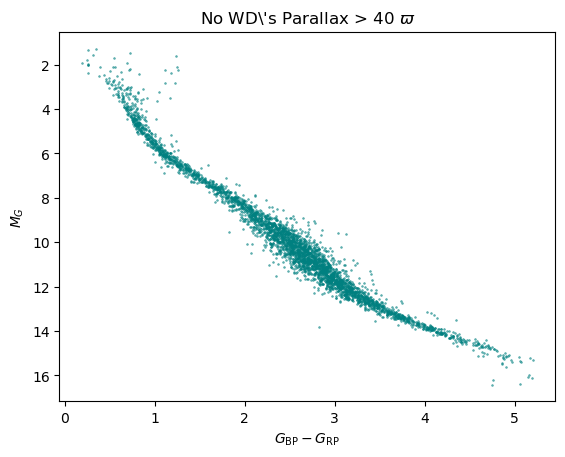

In [3]:
# first, step zero here, lets import the data
import pandas as pd
df = pd.read_csv('../../../../hub_data_share/gaiadr3_solar_neighborhood.csv')

# select only stars with parallax over 40
nearby_sel = df.parallax > 40
nearby_df = df[nearby_sel]

# remove white dwarfs
wd_color = (-0.4, 2)
wd_mg = (10, 16.5)

wd_sel = ((nearby_df.bp_rp > wd_color[0]) & (nearby_df.bp_rp < wd_color[1]) & (nearby_df.mg > wd_mg[0]) & (nearby_df.mg < wd_mg[1]))

nearby_nowd_df = nearby_df[~wd_sel]

# ploit the data
plt.scatter(nearby_nowd_df.bp_rp, nearby_nowd_df.mg ,color='teal', marker='*', s=1, alpha=0.5)
plt.gca().invert_yaxis()
plt.xlabel(r'$G_\mathrm{BP} - G_\mathrm{RP}$')
plt.ylabel(r'$M_G$')
plt.title(r'No WD\'s Parallax > 40 $\varpi$')

xlim = plt.xlim()
plt.show()

In [3]:
# x1, y1 = 0, 8
# x2, y2 = 3, 16.5
# m_div = (y2 - y1)/(x2 - x1)
# b_div = y1 - m_div * x1

where we'll be focusing on the objects with $M_G < m_\mathrm{div} (BP-RP) + b_\mathrm{div}$.

## 1. Construct a `NumPyro` model 
that models the population as a line, assuming $M_G$ to be distributed normally about this line with a standard deviation to be inferred from the data. 

Perform an MCMC.

In [4]:
# define linear model just like we used last time
mag = jnp.array(nearby_nowd_df.mg.values)
color = jnp.array(nearby_nowd_df.bp_rp.values)
# without outlier analysis
def linear_model(color=None, mag=None):
    # priors
    m = numpyro.sample('m', dist.Normal(loc=4.0, scale=10))
    b = numpyro.sample('b', dist.Normal(loc=-1.0, scale=100))
    σ = numpyro.sample('scatter', dist.Normal(scale=5))

    # Define the mean of the normal likelihood
    μ = numpyro.deterministic("μ", m * color + b)

    # Likelihood (sampling distribution) of observations
    with numpyro.plate("data", len(color)):
        obs = numpyro.sample('mag', dist.Normal(loc=μ, scale=σ), obs=mag)

In [5]:

start_time = time.time()

rng_key = random.PRNGKey(36)
rng_key, rng_key_ = random.split(rng_key)

kernel = infer.NUTS(linear_model)
num_samples = 1000
mcmc = infer.MCMC(
    kernel,
    num_chains=2,
    num_warmup=1000,
    num_samples=num_samples)
mcmc.run(rng_key_,
         color=color,
         mag=mag)

print(time.time() - start_time)
mcmc.print_summary()

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

9.020970344543457

                mean       std    median      5.0%     95.0%     n_eff     r_hat
         b      2.58      0.03      2.58      2.54      2.63    672.36      1.00
         m      2.94      0.01      2.94      2.92      2.95    686.66      1.01
   scatter      0.56      0.01      0.56      0.55      0.58    953.70      1.00

Number of divergences: 0


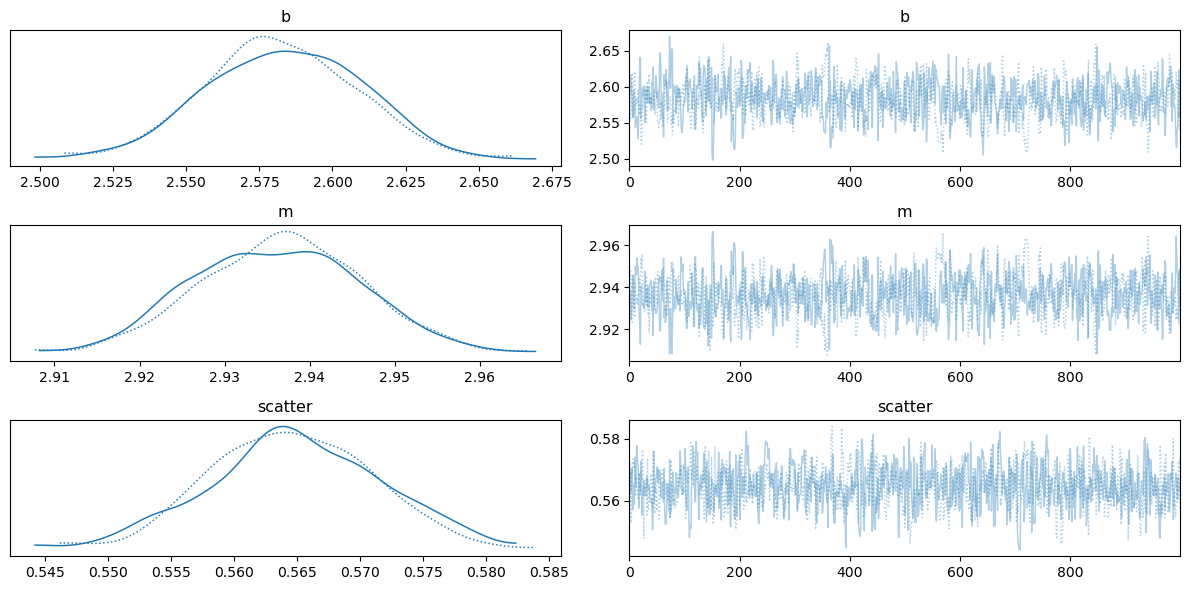

In [6]:
az.plot_trace(mcmc, var_names=["~μ"])
plt.tight_layout()

### A. Discuss 
the differences between the prior distributions you choose for your model parameters and the marginal (i.e., one-dimensional) posterior distributions estimated with your MCMC.  Did you choose suitably uninformed priors?

<font color='orange'> I chose normal priors and the posteriors are fairly normal as well so it seems that was a good choice for shape. The means of the priors and posteriors are all different. The posterior means are within the prior distributions which still makes them valid prior distributions. 

### B. Plot the models 
corresponding to 50 randomly chosen posterior samples from your MCMC.  

Discuss the quality of the fit, and in particular the role that the standard deviation parameter is playing in this fit.

In [5]:
def plot_data():
    # plt.errorbar(color, mag, yerr=σ, fmt=",k", ms=0, capsize=0, lw=1)
    plt.scatter(color, mag, marker="o", s=5, c="teal", label="data")
    plt.xlabel('BP-RP')
    plt.ylabel('Mag')
    plt.gca().invert_yaxis()

Text(0.5, 1.0, 'with random samples from the chain')

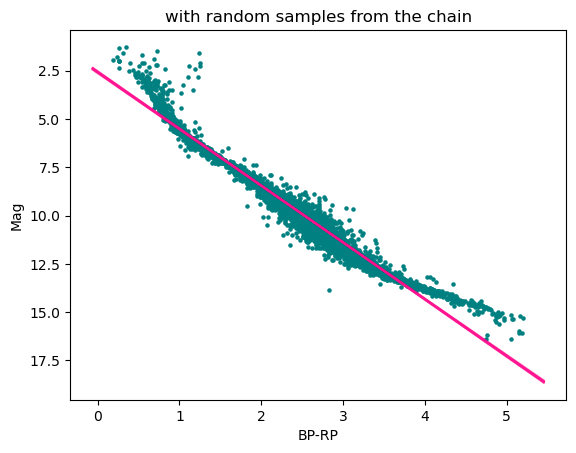

In [8]:
plot_data()
samples = mcmc.get_samples()
xlow, xhigh = plt.xlim()
x = jnp.linspace(xlow, xhigh, 100)


for i in random.choice(rng_key, num_samples, (50,)):
    mu = samples['m'][i] * x + samples['b'][i]
    plt.plot(x, mu, color='deeppink', alpha=0.1);
plt.title('with random samples from the chain')

<font color='orange'> The fit is decent for mose main sequance stars. We have deviation at the tails for high and low mass stars which both curve up and away.

## 2. Construct a new model 
that models the relation between $(BP-RP)$ and $M_G$ quadratically.  Carefully choose priors; be sure to explore choices for locations and scales that are appropriate for the new parameters.  

Run an MCMC.

In [9]:
# create new model
def quad_model(color=None, mag=None, σ=None):
    # priors
    a = numpyro.sample('a', dist.Normal(scale=100))
    b = numpyro.sample('b', dist.Normal(scale=100))
    c = numpyro.sample('c', dist.Normal(scale=100))

    σ = numpyro.sample('scatter', dist.HalfNormal(scale=5))

    # Define the mean of the normal likelihood
    μ = numpyro.deterministic("μ",  a*color**2 + b*color + c) 

    # Likelihood (sampling distribution) of observations
    with numpyro.plate("data", len(color)):
        obs = numpyro.sample('mag', dist.Normal(loc=μ, scale=σ), obs=mag)

In [10]:
start_time = time.time()

rng_key = random.PRNGKey(36)
rng_key, rng_key_ = random.split(rng_key)

kernel = infer.NUTS(quad_model)
num_samples = 5000
mcmc = infer.MCMC(
    kernel,
    num_chains=2,
    num_warmup=1000,
    num_samples=num_samples)
mcmc.run(rng_key_,
         color=color,
         mag=mag)

print(time.time() - start_time)
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

9.466995000839233

                mean       std    median      5.0%     95.0%     n_eff     r_hat
         a     -0.30      0.01     -0.30     -0.31     -0.29   2658.63      1.00
         b      4.40      0.03      4.40      4.35      4.45   2437.06      1.00
         c      1.06      0.04      1.06      1.00      1.12   2485.46      1.00
   scatter      0.44      0.01      0.44      0.44      0.45   4146.25      1.00

Number of divergences: 0


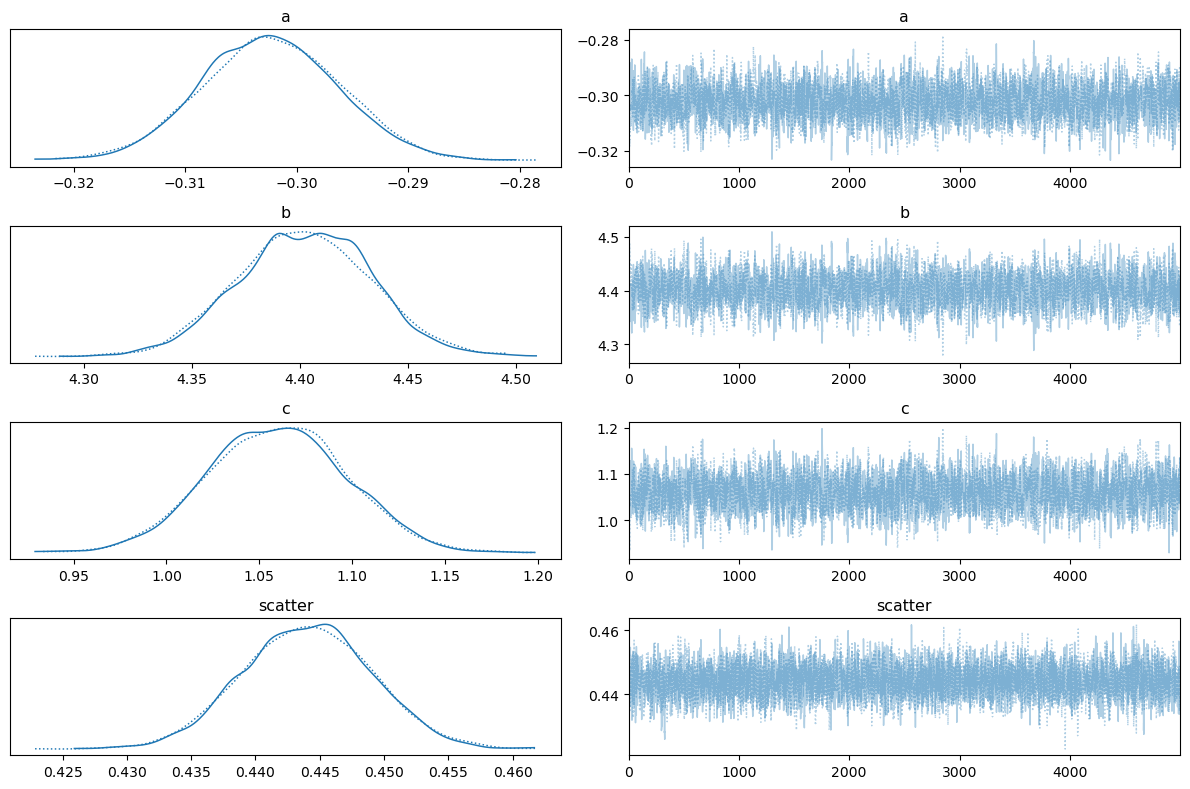

In [11]:
az.plot_trace(mcmc, var_names=["~μ"])
plt.tight_layout()

In [12]:
samples = mcmc.get_samples()
print(samples.keys())

dict_keys(['a', 'b', 'c', 'scatter', 'μ'])


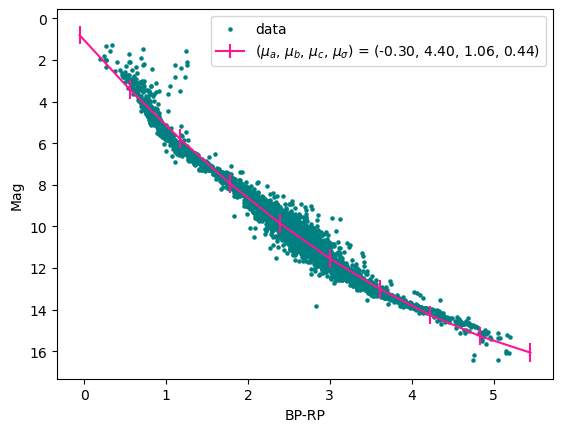

In [13]:
samples = mcmc.get_samples()

mean_a = jnp.mean(samples['a']).item()
mean_b = jnp.mean(samples['b']).item()
mean_c = jnp.mean(samples['c']).item()
mean_sigma = jnp.mean(samples['scatter']).item()

testx = jnp.linspace(xlow, xhigh, 10)
plot_data()

mu = mean_a * testx**2 + mean_b * testx + mean_c  # assuming quadratic model

plt.errorbar(
    testx,
    mu,
    yerr=mean_sigma,
    color='deeppink',
    label=fr'($\mu_a$, $\mu_b$, $\mu_c$, $\mu_\sigma$) = '
          fr'({mean_a:.2f}, {mean_b:.2f}, {mean_c:.2f}, {mean_sigma:.2f})'
)
plt.legend()
plt.show()


### A. Discuss 
the differences between the prior distributions you choose for your model parameters and the marginal (i.e., one-dimensional) posterior distributions estimated with your MCMC.  

Did you choose suitably uninformed priors?

<font color='orange'> My priors here were all centered at 0 with a scale of 100 so they had plenty of space for the mcmc to explore. If I constrained them more, it may have sped up computation time by a few seconds but that isn't much of a concern here since it is already fast. I would call these priors less weill informed and more *allowing*.

### B. Plot the model 
corresponding to 50 randomly chosen posterior samples from your MCMC.  

Discuss the quality of the fit.

Text(0.5, 1.0, 'Quadratic with random samples from the chain')

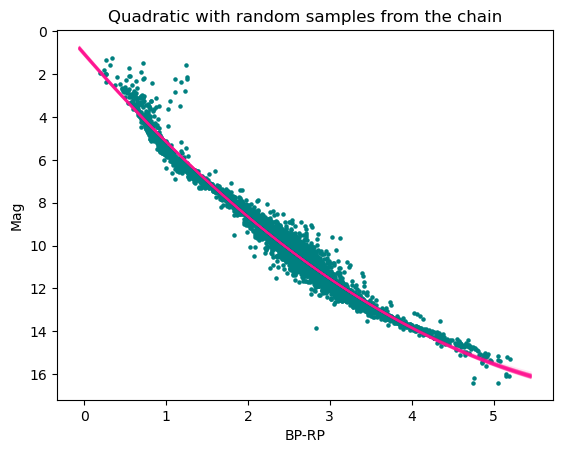

In [14]:
plot_data()
samples = mcmc.get_samples()
xlow, xhigh = plt.xlim()
x = jnp.linspace(xlow, xhigh, 100)


for i in random.choice(rng_key, num_samples, (50,)):
    mu = samples['a'][i] * x **2 + samples['b'][i] *  + samples['c'][i]
    plt.plot(x, mu, color='deeppink', alpha=0.1);
plt.title('Quadratic with random samples from the chain')

<font color='orange'> The quadratic model reasonably accounts for the high and low mass ends with only some outliers along the giant branch.

### C. **Graduate students:** 
Use your posterior estimates to predict the distribution we would expect for $M_G$ values of main sequence stars with color $(BP-RP) = 6$.

Text(0.5, 1.0, 'BP_RP = 6 Predictive Distribution')

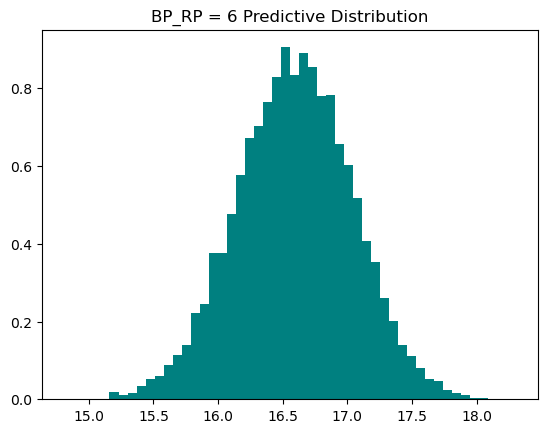

In [15]:
samples = mcmc.get_samples()

post_pred_samples = infer.Predictive(quad_model, samples)(
    rng_key_, color=jnp.array([6.0]), mag=None
)

posterior_pred_y = post_pred_samples['mag'].reshape(-1)

plt.hist(jnp.array(posterior_pred_y), bins=50, density=True, color='teal')
plt.title('BP_RP = 6 Predictive Distribution')

## 3. **Graduate students:** 
Explore higher order polynomials a bit.  How does the (qualitative) quality of the fit behave?

In [16]:
# create new polynomial model
def cubic_model(color=None, mag=None, σ=None):
    # priors
    a = numpyro.sample('a', dist.Normal(scale=100))
    b = numpyro.sample('b', dist.Normal(scale=100))
    c = numpyro.sample('c', dist.Normal(scale=100))
    d = numpyro.sample('d', dist.Normal(scale=100))

    σ = numpyro.sample('scatter', dist.HalfNormal(scale=20))

    # Define the mean of the normal likelihood
    μ = numpyro.deterministic("μ",  a*color**3 + b*color**2 + c*color + d) 

    # Likelihood (sampling distribution) of observations
    with numpyro.plate("data", len(color)):
        obs = numpyro.sample('mag', dist.Normal(loc=μ, scale=σ), obs=mag)

In [17]:
start_time = time.time()

rng_key = random.PRNGKey(36)
rng_key, rng_key_ = random.split(rng_key)

kernel = infer.NUTS(cubic_model)
num_samples = 1000
mcmc = infer.MCMC(
    kernel,
    num_chains=2,
    num_warmup=1000,
    num_samples=num_samples)
mcmc.run(rng_key_,
         color=color,
         mag=mag)

print(time.time() - start_time)
mcmc.print_summary()

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

9.71694302558899

                mean       std    median      5.0%     95.0%     n_eff     r_hat
         a     -0.02      0.01     -0.02     -0.03     -0.01    366.92      1.00
         b     -0.17      0.04     -0.17     -0.24     -0.10    358.60      1.00
         c      4.10      0.10      4.10      3.93      4.26    355.88      1.00
         d      1.25      0.07      1.24      1.13      1.36    366.05      1.01
   scatter      0.44      0.01      0.44      0.43      0.45    750.49      1.00

Number of divergences: 0


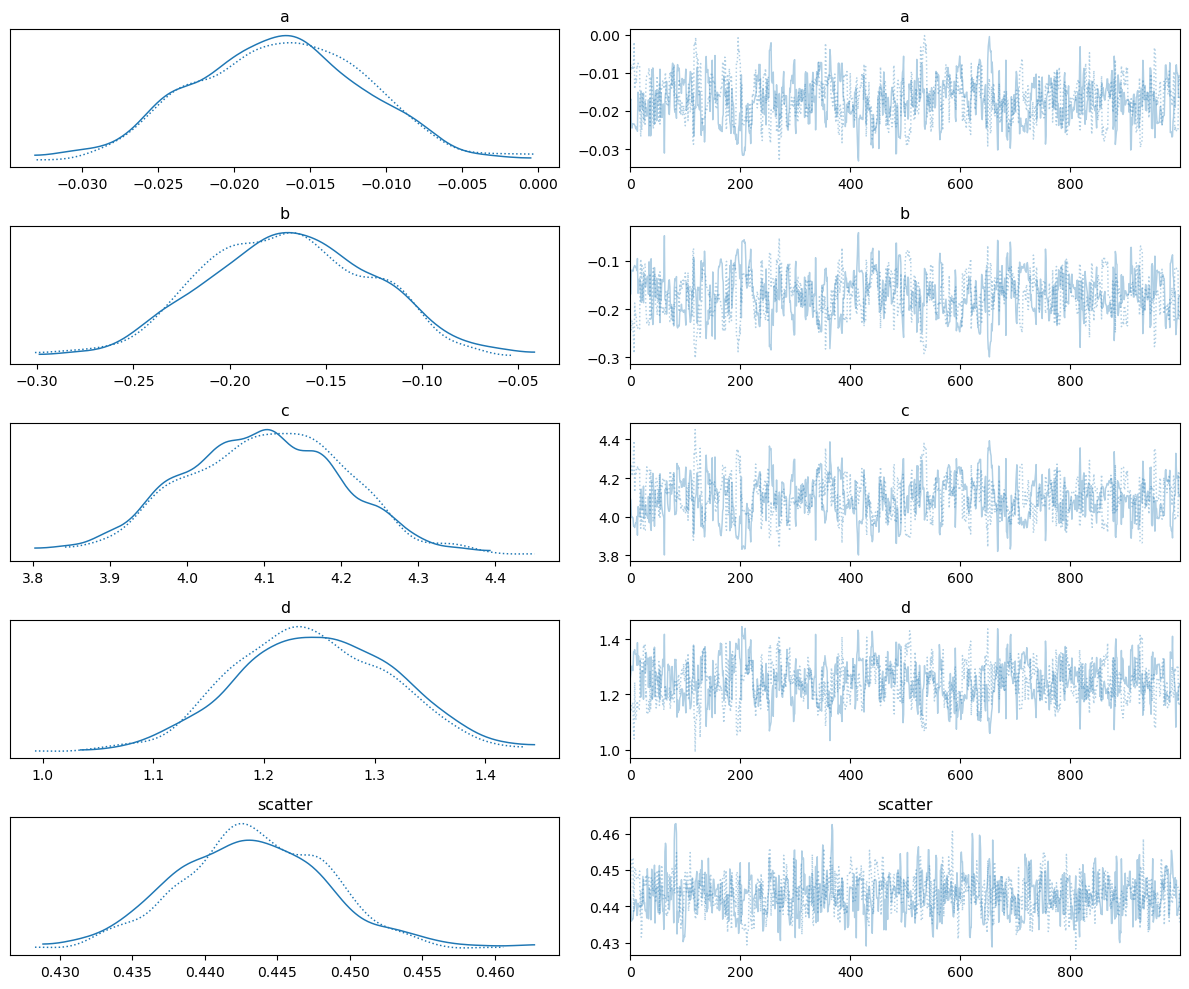

In [18]:
az.plot_trace(mcmc, var_names=["~μ"])
plt.tight_layout()

In [19]:
samples = mcmc.get_samples()
print(samples.keys())

dict_keys(['a', 'b', 'c', 'd', 'scatter', 'μ'])


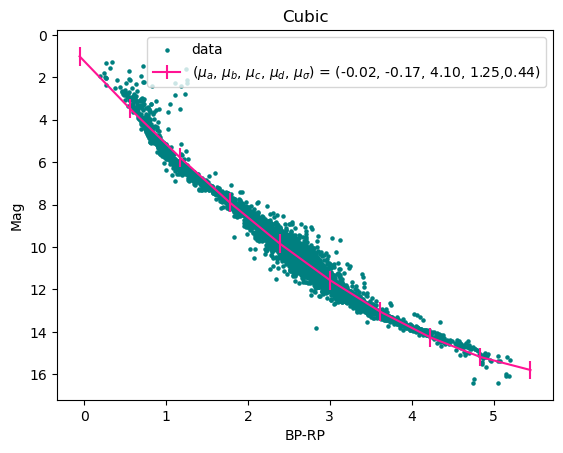

In [20]:
samples = mcmc.get_samples()

mean_a = jnp.mean(samples['a']).item()
mean_b = jnp.mean(samples['b']).item()
mean_c = jnp.mean(samples['c']).item()
mean_d = jnp.mean(samples['d']).item()
mean_sigma = jnp.mean(samples['scatter']).item()

testx = jnp.linspace(xlow, xhigh, 10)
plot_data()

mu = mean_a * testx**3 + mean_b * testx**2 + mean_c * testx + mean_d  # assuming quadratic model

plt.errorbar(
    testx,
    mu,
    yerr=mean_sigma,
    color='deeppink',
    label=fr'($\mu_a$, $\mu_b$, $\mu_c$, $\mu_d$, $\mu_\sigma$) = '
          fr'({mean_a:.2f}, {mean_b:.2f}, {mean_c:.2f}, {mean_d:.2f},{mean_sigma:.2f})'
)
plt.legend()
plt.title('Cubic')
plt.show()


Text(0.5, 1.0, ' Cubic with random samples from the chain')

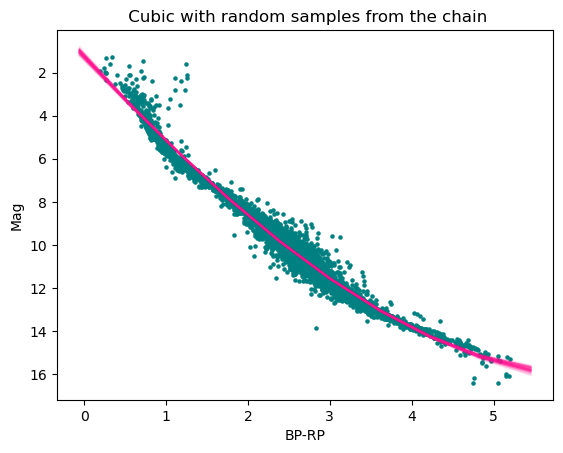

In [21]:
plot_data()
xlow, xhigh = plt.xlim()
x = jnp.linspace(xlow, xhigh, 10)


for i in random.choice(rng_key, num_samples, (50,)):
    mu = samples['a'][i] * x**3 + samples['b'][i]*x**2 + x * samples['c'][i] + samples['d'][i]
    plt.plot(x, mu, color='deeppink', alpha=0.1);
plt.title(' Cubic with random samples from the chain')

##### <font color='orange'> Comparison with Quartic
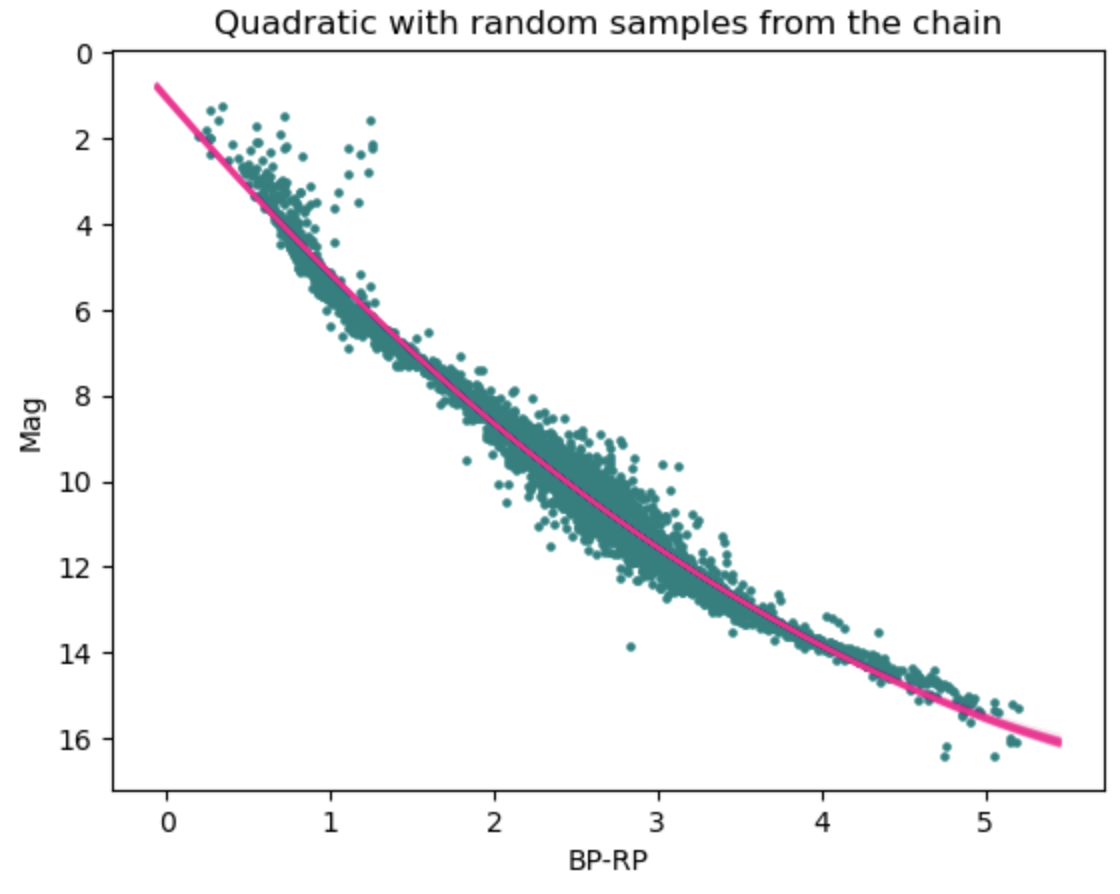

<font color='orange'> I don't think a cubic function fits better since we can see it does not account for the inward/quadratically turning tails as well, particularly onthe high mass end.

# Part II

Now let's bring the white dwarfs back into the mix, focusing on all the objects with parallax > 40 milliarcseconds.

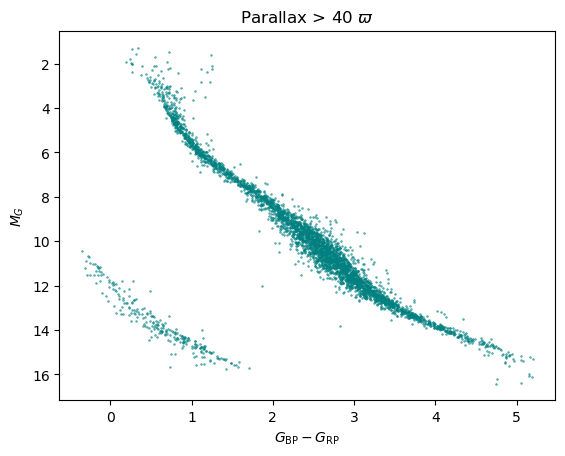

In [22]:
plt.scatter(nearby_df.bp_rp, nearby_df.mg ,color='teal', marker='*', s=1, alpha=0.5)
plt.gca().invert_yaxis()
plt.xlabel(r'$G_\mathrm{BP} - G_\mathrm{RP}$')
plt.ylabel(r'$M_G$')
plt.title(r'Parallax > 40 $\varpi$')

xlim = plt.xlim()
plt.show()

## 1. Construct a mixture model with `NumPyro` 
that simultaneously describes the main sequence stars and white dwarfs, each described by a linear relationship with its own slope, y-intercept, and scatter of observations about it.

### **Tips:**

1. Recall our outlier model we built, which outlines the machinery for building a mixture model that allows for our data to be described by more than one distribution.

2. Our model will now be composed of two lines.  If we impose the same priors for the parameters of each line, then the two lines will be degenerate and sampling gets unnecessarily tricky.  There are many ways we could avoid this degeneracy, but for now I suggest imposing unique priors on the y-intercepts.  I also recommend a relatively narrow prior on the slopes of the lines to get the model from trying crazy solutions:


        m_ms = numpyro.sample('m_ms', dist.Uniform(2, 5))
    
        b_ms = numpyro.sample('b_ms', dist.Uniform(0, 5))

        m_wd = numpyro.sample('m_wd', dist.Uniform(2, 5))
        
        b_wd = numpyro.sample('b_wd', dist.Uniform(10, 15))


In [6]:
x = jnp.array(nearby_df['bp_rp'])
y = jnp.array(nearby_df['mg'])

In [24]:
def mixture_model(x=None, y=None, sigma_y=None):
        m_ms = numpyro.sample('m_ms', dist.Uniform(2, 5))
        b_ms = numpyro.sample('b_ms', dist.Uniform(0, 5))
        mu_ms = m_ms * x + b_ms
        sigma_y = numpyro.sample('sigma_y', dist.HalfNormal(scale=5))
        dist_ms = dist.Normal(mu_ms, sigma_y)
        
        m_wd = numpyro.sample('m_wd', dist.Uniform(2, 5))
        b_wd = numpyro.sample('b_wd', dist.Uniform(10, 15))
        mu_wd = m_wd * x + b_wd
        dist_wd = dist.Normal(mu_wd, sigma_y)

        P_ms = numpyro.sample('P_ms', dist.Uniform(0, 1)) # Prob an observation will be in the foreground

    # Define the foreground/background parameters, with equal probability between categories
        mixing_dist = dist.Categorical(probs=jnp.array([P_ms, 1 - P_ms]))
    ### give it the prob of being in one model or the other and then give it the categories fo the model
    ### let the data tell us what is an outlier
        mixture = dist.MixtureGeneral(mixing_dist, [dist_ms, dist_wd])

    # Likelihood
    ### build giant distribution. this is the thing with 1 and 1-q in the other we saw above
        with numpyro.plate("data", len(x)):
            y_ = numpyro.sample("obs", mixture, obs=y) #y_ to disinguish from y

            # Until here, where we can track the membership probability of each sample
            log_probs = mixture.component_log_probs(y_)
            ### determinisitic is the thing that is going to marginalize over those, Re: The final equation above
            numpyro.deterministic(
                "log_p_ms", log_probs - jax.nn.logsumexp(log_probs, axis=-1, keepdims=True)
            )

In [25]:
# Generate a starting key, which we'll split for later operations.
rng_key = random.PRNGKey(3)
rng_key, rng_key_ = random.split(rng_key)

kernel = infer.NUTS(mixture_model)
num_samples = 5000
mcmc = infer.MCMC(
    kernel,
    num_chains=2,
    num_warmup=1000,
    num_samples=num_samples)
mcmc.run(rng_key_,
         x=x,
         y=y
        )
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
      P_ms      0.94      0.00      0.94      0.93      0.94   9606.74      1.00
      b_ms      2.59      0.03      2.59      2.54      2.63   4977.75      1.00
      b_wd     12.18      0.06     12.18     12.08     12.27   6133.45      1.00
      m_ms      2.94      0.01      2.94      2.92      2.95   5052.94      1.00
      m_wd      2.50      0.08      2.50      2.37      2.62   5868.38      1.00
   sigma_y      0.56      0.01      0.56      0.55      0.57   9971.55      1.00

Number of divergences: 0


## 2. Plot the two lines 
for each of 50 randomly chosen posterior samples from your MCMC.  

Discuss the quality of the fits, and in particular the constraints.  Is the model able to identify the two populations?

In [26]:
samples = mcmc.get_samples()
print(samples.keys())

dict_keys(['P_ms', 'b_ms', 'b_wd', 'log_p_ms', 'm_ms', 'm_wd', 'sigma_y'])


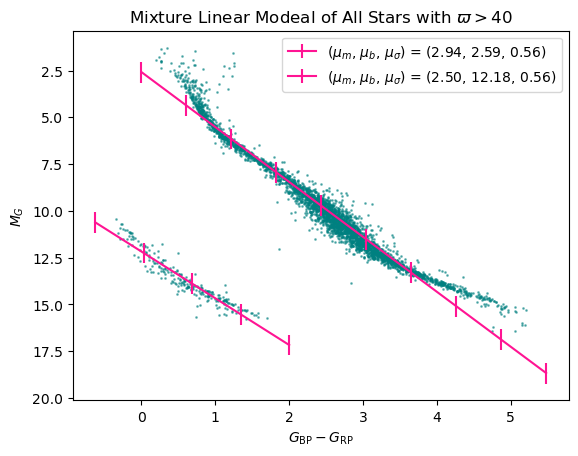

In [27]:
samples = mcmc.get_samples()

mean_m_ms = jnp.mean(samples['m_ms']).item()
mean_b_ms = jnp.mean(samples['b_ms']).item()
mean_m_wd = jnp.mean(samples['m_wd']).item()
mean_b_wd = jnp.mean(samples['b_wd']).item()
mean_sigma = jnp.mean(samples['sigma_y']).item()

plt.scatter(nearby_df.bp_rp, nearby_df.mg, s=1, alpha=0.5, color='teal')
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")
plt.gca().invert_yaxis()

xlow, xhigh = plt.xlim()
testx_ms = jnp.linspace(0, xhigh, 10)
testx_wd = jnp.linspace(xlow, 2, 5)

mu_ms = mean_m_ms * testx_ms + mean_b_ms
mu_wd = mean_m_wd * testx_wd + mean_b_wd

plt.errorbar(
    testx_ms,
    mu_ms,
    yerr=mean_sigma,
    color='deeppink',
    label=fr'($\mu_m$, $\mu_b$, $\mu_\sigma$) = '
          fr'({mean_m_ms:.2f}, {mean_b_ms:.2f}, {mean_sigma:.2f})'
)

plt.errorbar(
    testx_wd,
    mu_wd,
    yerr=mean_sigma,
    color='deeppink',
    label=fr'($\mu_m$, $\mu_b$, $\mu_\sigma$) = '
          fr'({mean_m_wd:.2f}, {mean_b_wd:.2f}, {mean_sigma:.2f})'
)
plt.legend()
plt.title(r'Mixture Linear Modeal of All Stars with $\varpi > 40$')
plt.show()


<font color='orange'> The model is able to succesfully identify the two populations. A double quadratic model would fit both better since both have the similar deviations from the linear line.

## 3. **Graduate students:**

### A. Plot a distribution 
of the probabilities that each star in our catalog is on the main sequence.  

Are there any stars which aren't confidently associated with a particular population?

In [33]:
print(samples.keys())

dict_keys(['P_ms', 'b_ms', 'b_wd', 'log_p_ms', 'm_ms', 'm_wd', 'sigma_y'])


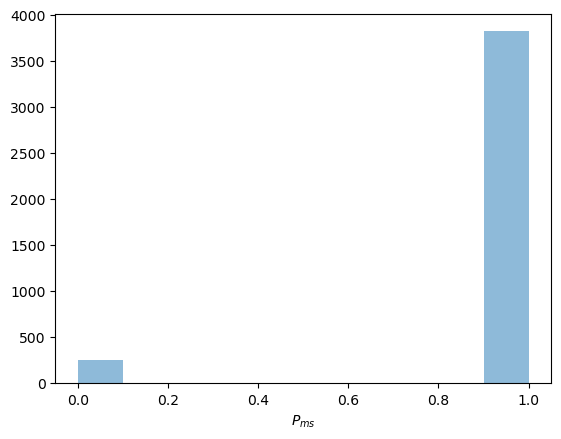

In [45]:
# probability it is in the main sequence
p_ms = jnp.mean(jnp.exp(samples['log_p_ms'][..., 0]), axis=0)
plt.hist(p_ms, alpha=0.5) # Plot for the first data point
plt.xlabel("$P_{ms}$")
plt.show()

<font color='orange'> Wow very bimodal. There is not much uncertainty of wether or not the star is in the main sequence or not. Let's test that by taking a look at the mean uncertainty.

In [40]:
sigma_p_ms = jnp.mean(jnp.std(jnp.exp(samples["log_p_ms"][..., 0]), axis=0), axis=0)
print(f'Mean Uncertainty in p_ms:  {str(sigma_p_ms)}')

Mean Uncertainty in p_ms:  2.447337e-08


<font color='orange'> Absolutely tiny. That tracks.

/tmp/ipykernel_404/1634554533.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


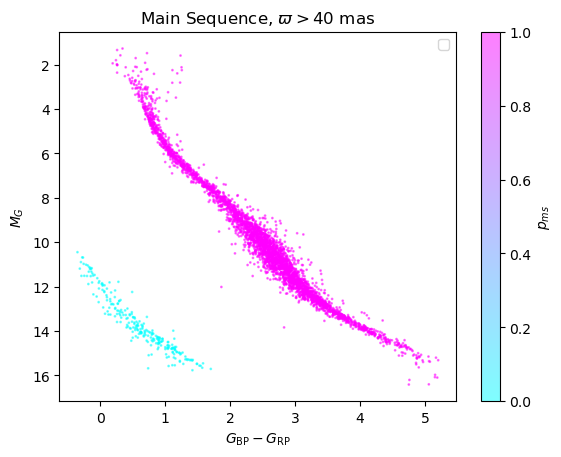

In [52]:
# throw that onto a color map of the data
sc = plt.scatter(nearby_df.bp_rp, nearby_df.mg, s=1, alpha=0.5, c=p_ms, cmap='cool')
plt.colorbar(label=r'$p_{ms}$')
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")
plt.gca().invert_yaxis()
sc.set_alpha(0.5)
xlow, xhigh = plt.xlim()
plt.legend()
plt.show()

### B. Relax the priors on slope and y-intercept and run an MCMC:


    m_ms = numpyro.sample('m_ms', dist.Normal(scale=10))
    b_ms = numpyro.sample('b_ms', dist.Normal(scale=20))

    m_wd = numpyro.sample('m_wd', dist.Normal(scale=10))
    b_wd = numpyro.sample('b_wd', dist.Normal(scale=20))


In [7]:
def mixture_relaxed_model(x=None, y=None, sigma_y=None):
        m_ms = numpyro.sample('m_ms', dist.Normal(scale=10))
        b_ms = numpyro.sample('b_ms', dist.Normal(scale=20))
        mu_ms = m_ms * x + b_ms
        sigma_y = numpyro.sample('sigma_y', dist.HalfNormal(scale=5))
        dist_ms = dist.Normal(mu_ms, sigma_y)
        
        m_wd = numpyro.sample('m_wd', dist.Normal(scale=10))
        b_wd = numpyro.sample('b_wd', dist.Normal(scale=20))
        mu_wd = m_wd * x + b_wd
        dist_wd = dist.Normal(mu_wd, sigma_y)

        P_ms = numpyro.sample('P_ms', dist.Uniform(0, 1)) # Prob an observation will be in the foreground

    # Define the foreground/background parameters, with equal probability between categories
        mixing_dist = dist.Categorical(probs=jnp.array([P_ms, 1 - P_ms]))
    ### give it the prob of being in one model or the other and then give it the categories fo the model
    ### let the data tell us what is an outlier
        mixture = dist.MixtureGeneral(mixing_dist, [dist_ms, dist_wd])

    # Likelihood
    ### build giant distribution. this is the thing with 1 and 1-q in the other we saw above
        with numpyro.plate("data", len(x)):
            y_ = numpyro.sample("obs", mixture, obs=y) #y_ to disinguish from y

            # Until here, where we can track the membership probability of each sample
            log_probs = mixture.component_log_probs(y_)
            ### determinisitic is the thing that is going to marginalize over those, Re: The final equation above
            numpyro.deterministic(
                "log_p_ms", log_probs - jax.nn.logsumexp(log_probs, axis=-1, keepdims=True)
            )

In [8]:
# Generate a starting key, which we'll split for later operations.
rng_key = random.PRNGKey(3)
rng_key, rng_key_ = random.split(rng_key)

kernel = infer.NUTS(mixture_relaxed_model)
num_samples = 5000
mcmc = infer.MCMC(
    kernel,
    num_chains=2,
    num_warmup=1000,
    num_samples=num_samples)
mcmc.run(rng_key_,
         x=x,
         y=y
        )
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
      P_ms      0.50      0.44      0.50      0.06      0.94      1.00    135.77
      b_ms      7.38      4.80      7.33      2.54     12.24      1.00    122.62
      b_wd      7.38      4.80      7.31      2.54     12.23      1.00    123.77
      m_ms      2.72      0.23      2.83      2.43      2.96      1.03      4.83
      m_wd      2.72      0.22      2.84      2.44      2.96      1.03      4.89
   sigma_y      0.56      0.01      0.56      0.55      0.57  10180.98      1.00

Number of divergences: 0


### Take a look at the trace plots and the fits to the data.  Can you describe what's happening?

In [10]:
print(mcmc.get_samples().keys())

dict_keys(['P_ms', 'b_ms', 'b_wd', 'log_p_ms', 'm_ms', 'm_wd', 'sigma_y'])


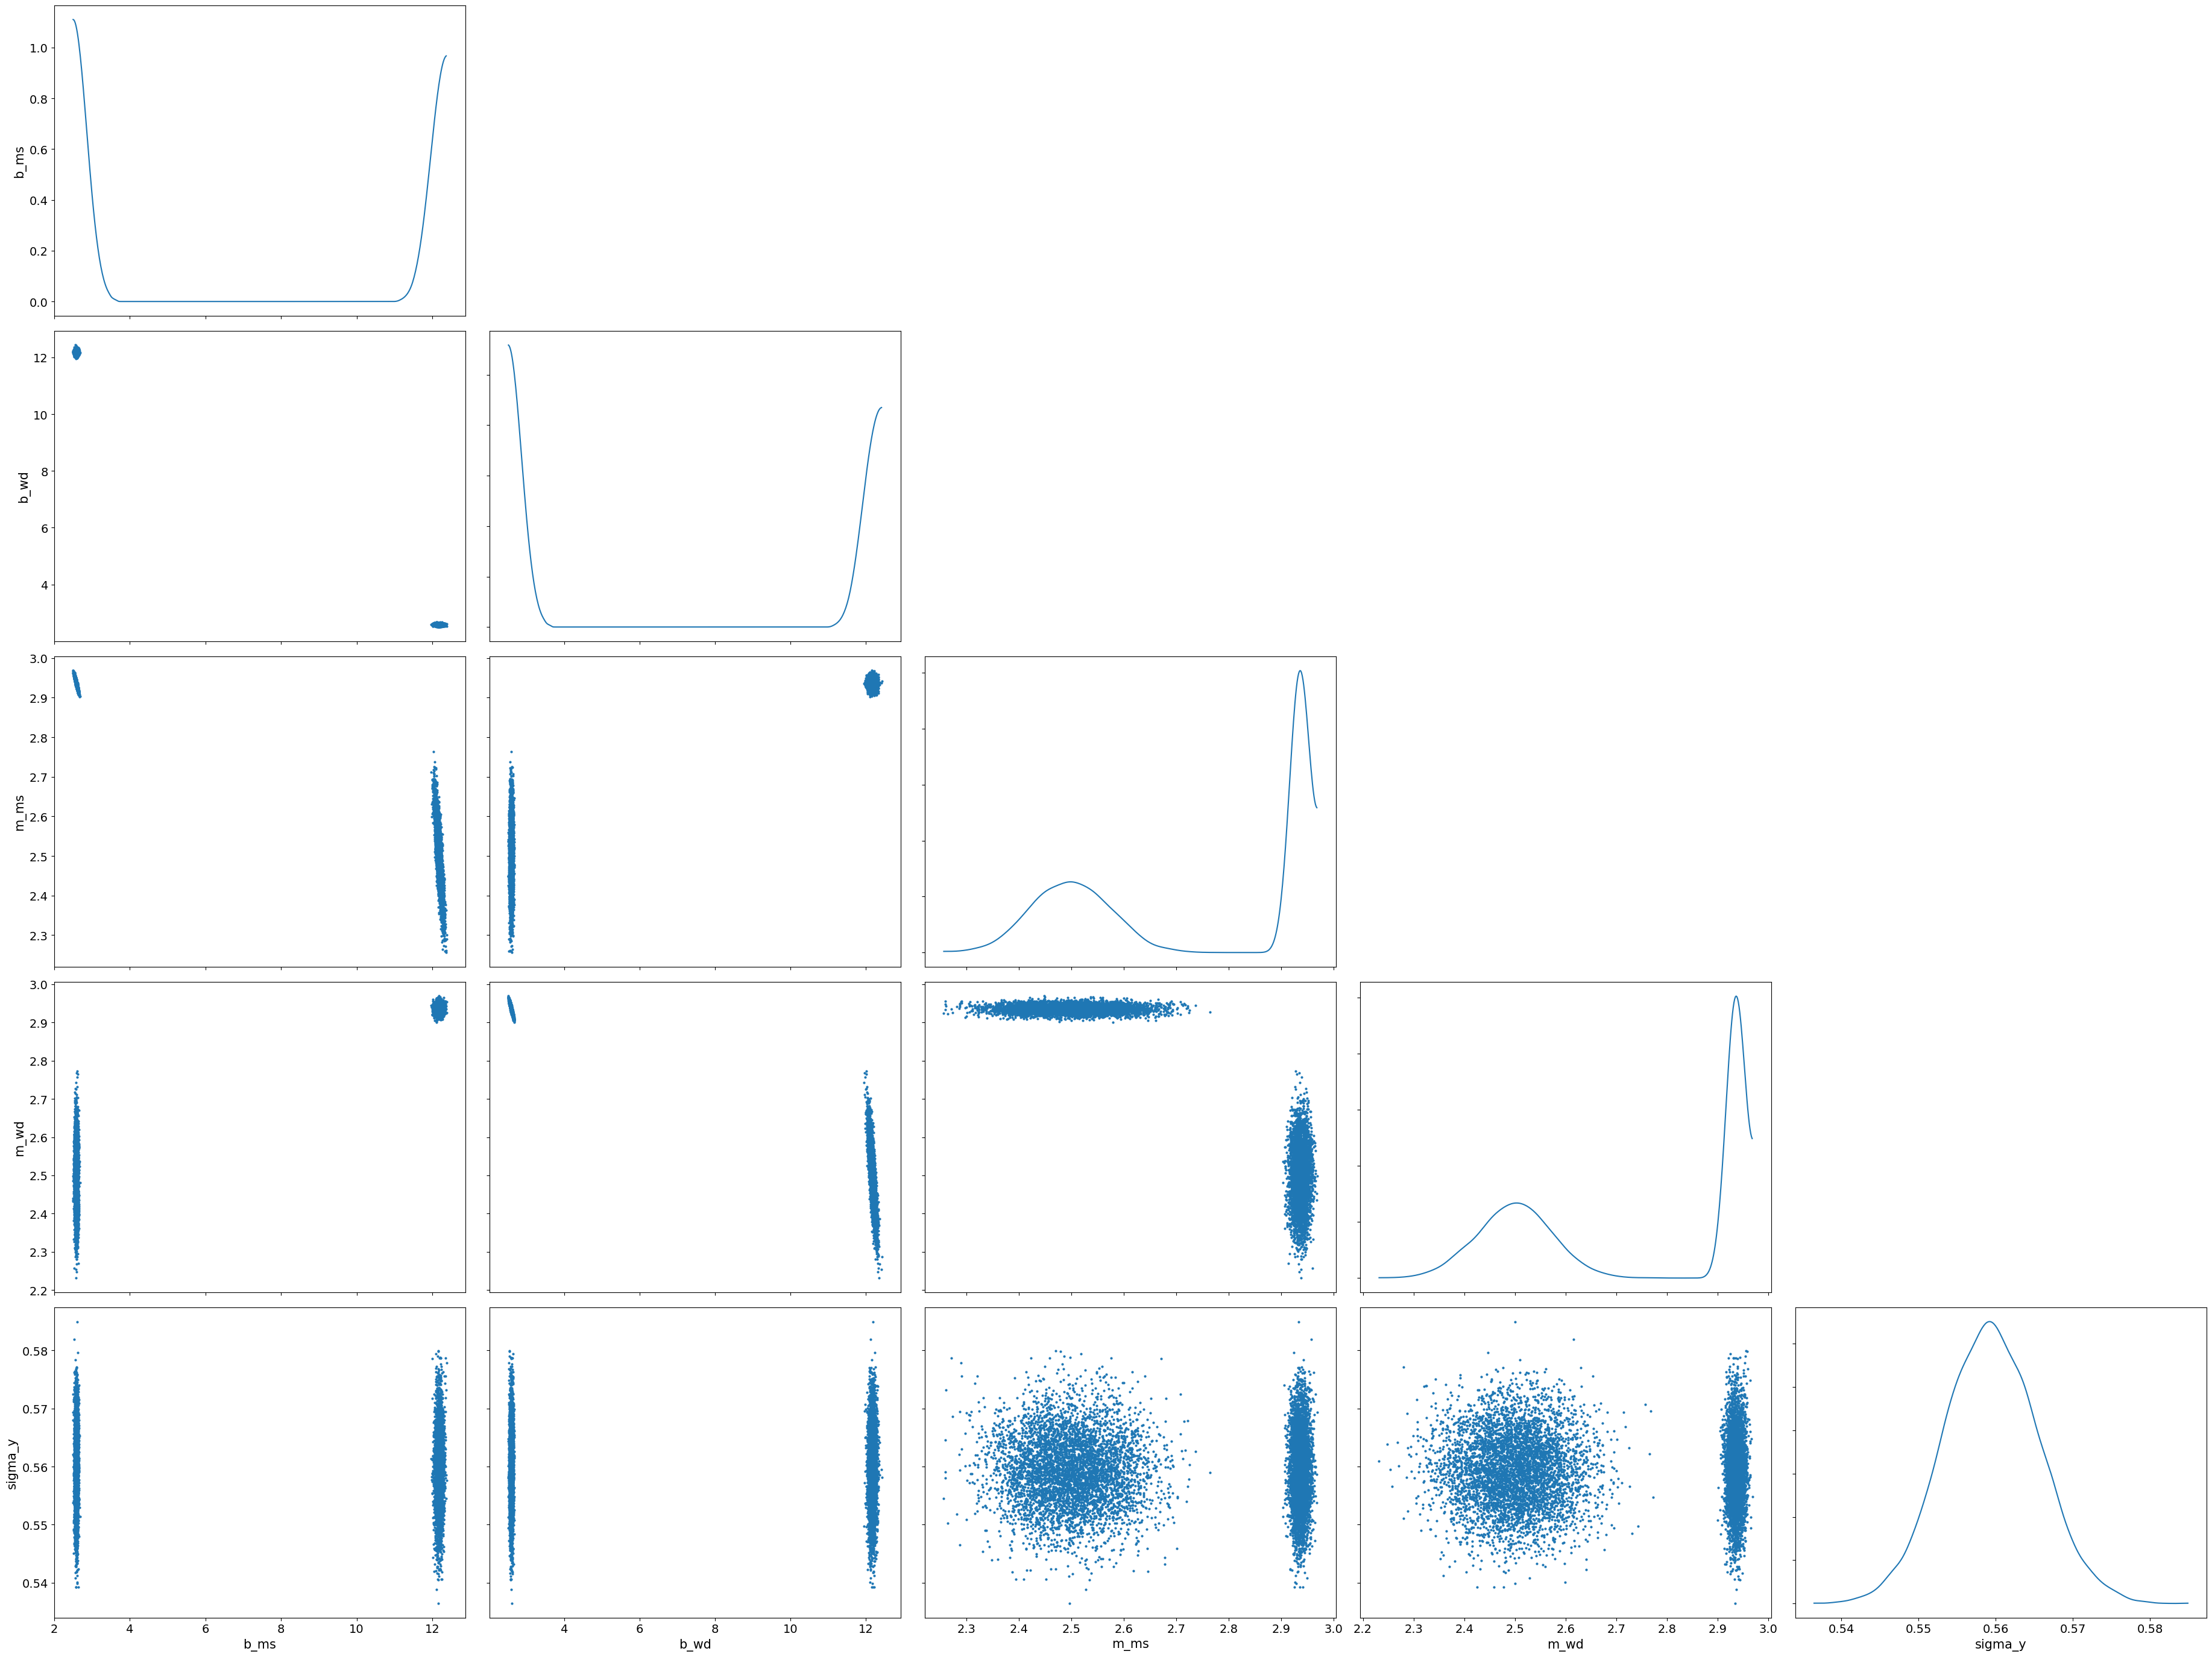

In [11]:
az.plot_pair(mcmc, var_names=["b_ms","b_wd","m_ms","m_wd","sigma_y"], marginals=True)
plt.tight_layout()
plt.show()

<font color='orange'> Because we relaxed the priors, the mcmc is exploring the whole space, MS and WD at the same time. The result is that we do not have any distinguishment between the line for the WD's and MS's. 

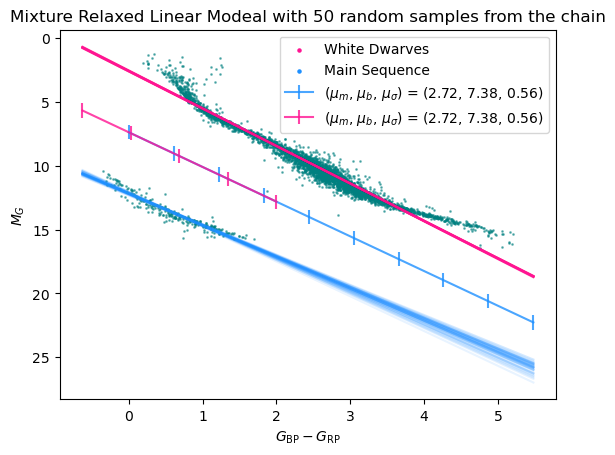

In [32]:
samples = mcmc.get_samples()

mean_m_ms = jnp.mean(samples['m_ms']).item()
mean_b_ms = jnp.mean(samples['b_ms']).item()
mean_m_wd = jnp.mean(samples['m_wd']).item()
mean_b_wd = jnp.mean(samples['b_wd']).item()
mean_sigma = jnp.mean(samples['sigma_y']).item()

plt.scatter(nearby_df.bp_rp, nearby_df.mg, s=1, alpha=0.5, color='teal')
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")
plt.gca().invert_yaxis()

xlow, xhigh = plt.xlim()
testx_ms = jnp.linspace(0, xhigh, 10)
testx_wd = jnp.linspace(xlow, 2, 5)

mu_ms = mean_m_ms * testx_ms + mean_b_ms
mu_wd = mean_m_wd * testx_wd + mean_b_wd

plt.errorbar(
    testx_ms,
    mu_ms,
    yerr=mean_sigma,
    color='dodgerblue',
    alpha=0.8,
    label=fr'($\mu_m$, $\mu_b$, $\mu_\sigma$) = '
          fr'({mean_m_ms:.2f}, {mean_b_ms:.2f}, {mean_sigma:.2f})'
)

plt.errorbar(
    testx_wd,
    mu_wd,
    yerr=mean_sigma,
    color='deeppink',
    alpha=0.8,
    label=fr'($\mu_m$, $\mu_b$, $\mu_\sigma$) = '
          fr'({mean_m_wd:.2f}, {mean_b_wd:.2f}, {mean_sigma:.2f})'
)

testx = jnp.linspace(xlow, xhigh, 100)
for i in random.choice(rng_key, num_samples, (50,)):
    mu_ms = samples['b_ms'][i] + samples['m_ms'][i] * testx
    plt.plot(testx, mu_ms, color='dodgerblue', alpha=0.1);

for i in random.choice(rng_key, num_samples, (50,)):
    mu_wd = samples['b_wd'][i] + samples['m_wd'][i] * testx
    plt.plot(testx, mu_wd, color='deeppink', alpha=0.1);

plt.scatter([], [], s=5, alpha=1, color='deeppink', label='White Dwarves')

plt.scatter([], [], s=5, alpha=1, color='dodgerblue', label='Main Sequence')
 
    
plt.legend()
plt.title(r'Mixture Relaxed Linear Modeal with 50 random samples from the chain')
plt.show()


<font color='orange'> We can see that the mcmc *is* fitting for both WD's and MS stars. We an see that there are local maxima in the WD and MS regions however the mean of both the WD and MS line as at the same location. The chain for the WD paramaters are also exploring the MS space and vice versa. INTERESTINGLY, the first 50 samples if the WD chain are plotted in the MS region! Similarly for MS, the first 50 samples are on the WD's! It is not doing a good job of modelling either.